## <center>Análisis y Procesamiento de Señales<center/>
# <center>TS1: "Síntesis y operaciones de señales"<center/>
## <center>1er Cuatrimeste 2026<center/>
### <center>Alumno : D'Alesio Alejo<center/>

### 1.1 Señal sinusoidal de 2KHz. 

Inicialmente genero una señal sinusoidal de 2 KHz. La señal esta compuesta por:
- vmax = Amplitud máxima de la señal.
- dc = Offset, desplaza la señal para arriba o para abajo.
- ff = Frecuencia de la señal ( ciclos por segundo).
- ph = Fase.
- nn = Cantidad de muestras. 
- fm = Frecuencia de muestreo.


In [71]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen(vmax, dc, fs, ph, nn, fm):

    tt = np.arange(nn) / fm 
    xx = dc + vmax * np.sin(2 * np.pi * fs * tt + ph)

    return tt, xx

Al ser una señal con una frecuencia de 2 KHz, por Nyquist la frecuencia de muestreo teórico debe ser fm > 2fs. En la práctica se observa que la frecuencia de muestreo debe ser mucho mas grande que 2fs, por lo tanto elegí un valor de fm = 100000 Hz y una cantidad de muestras de N = 200. De esta forma, el tiempo entre cada muestra será de $ T = \frac{1}{100000} = 10^{-5} s $

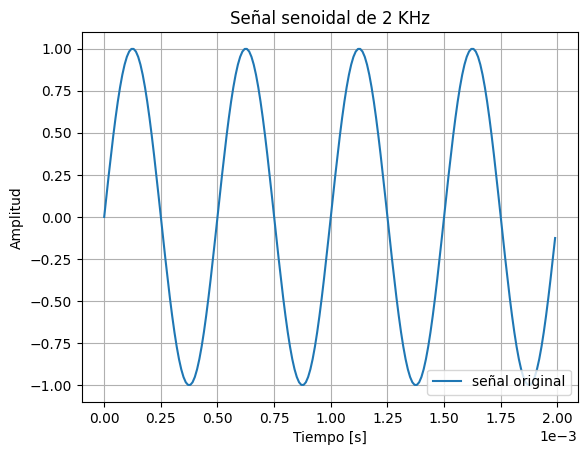

In [72]:
vmax = 1
dc = 0
fs = 2000 
ph = 0
nn = 200
fm = 100000 

tt, xx = mi_funcion_sen(vmax, dc, fs, ph, nn, fm)

potencia_senoidal = np.mean(xx**2)


plt.figure()

plt.plot(tt, xx, label='señal original')

plt.title('Señal senoidal de 2 KHz')   # título
plt.xlabel('Tiempo [s]')                 # eje x
plt.ylabel('Amplitud')                   # eje y
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) #sgrego notacion cientifica en eje x

plt.grid(True)                           # grilla
plt.legend(loc='lower right')                             # muestra el label

plt.show()

Como resultado se obtiene una señal senoidal de 4 ciclos, donde al ser una señal periódica tendrá una determinada potencia.

In [73]:
potencia_senoidal = np.mean(xx**2)

print(f"La potencia de la señal es de {potencia_senoidal} Watts")

La potencia de la señal es de 0.5 Watts


### 1.2. Señal amplificada y desfazada en π/2. 

En este caso, la función utilizada para generar la señal senoidal será la misma, manteniendo la cantidad de muestras de N = 200 y una distancia entre muestras de $ T = 10^{-5} s $. 

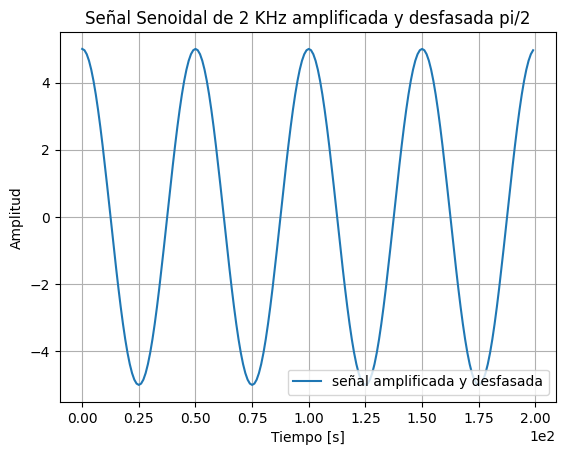

In [74]:
vmax1 = 5 #(amplifico la señal 5 veces)
dc1 = 0
fs1 = 2000 
ph1 = np.pi/2 #desfasada pi/2
nn1 = 200
fm1 = 100000 

tt, xx_ampl_y_desf = mi_funcion_sen(vmax1, dc1, fs1, ph1, nn1, fm1)

plt.figure()


plt.plot(xx_ampl_y_desf, label='señal amplificada y desfasada')

plt.title('Señal Senoidal de 2 KHz amplificada y desfasada pi/2')   
plt.xlabel('Tiempo [s]')                 # eje x
plt.ylabel('Amplitud')                   # eje y
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) #agrego notacion cientifica en eje x

plt.grid(True)                           # grilla
plt.legend(loc='lower right')                             # muestra el label

plt.show()

De esta manera se obtiene una señal desfasada $ pi/2 $ y amplificada 5 veces la señal original.
    En el caso de la potencia, al tratarse de una señal amplificada, este valor será mayor que la de la señal original debido a que la potencia depende de la amplitud.

In [75]:
potencia_senoidal_ampl_y_desf = np.mean(xx_ampl_y_desf**2)

print(f"La potencia de la señal es de {potencia_senoidal_ampl_y_desf} Watts")

La potencia de la señal es de 12.5 Watts


### 1.3. Señal modulada en amplitud por otra señal sinusoidal de la mitad de la frecuencia.

La modulación es el proceso de colocar la información contenida en una señal electrónica de baja frecuencia en una señal de alta frecuencia. La señal modulada en amplitud esta compuesta por dos señales, una denominada Señal Portadora y otra Señal Moduladora/Envolvente . La señal portadora será una señal de alta frecuencia que transportará la información y la señal moduladora será una señal de baja frecuencia que contendrá la información. 

En nuestro caso, la señal Moduladora será una señal con una frecuencia de 1000 Hz y la Señal Portadora tendrá una frecuencia de 2000 Hz. Ambas señales son generadas utilizando una cantidad de muestras N = 200 y una distancia entre muestras de $ T = 10^{-5} s $.

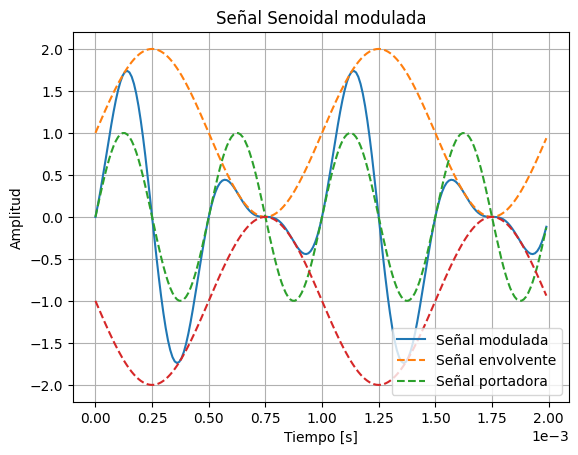

In [76]:
def mi_funcion_sen_envolvente(vmax2, dc2, fs2, ph2, nn2, fm2):

    tt2 = np.arange(nn2) / fm2 
    xx2 = dc2 + vmax2*(1 + np.sin(2 * np.pi * fs2 * tt2 + ph2))

    return tt2, xx2

vmax2 = 1
dc2 = 0
fs2 = 2000/2 #mitad de frecuencia de señal original (cantidad de ciclos por segundo)
ph2 = 0 
nn2 = 200
fm2 = 100000 


tt2, xx2 = mi_funcion_sen_envolvente(vmax2, dc2, fs2, ph2, nn2, fm2)

señal_modulada = xx*xx2

plt.figure()


plt.plot(tt, señal_modulada, label='Señal modulada')
plt.plot(tt, xx2, '--', label='Señal envolvente')
plt.plot(tt,xx, '--', label = 'Señal portadora')
plt.plot(tt, -xx2, '--')   #envolvente inferior

plt.title('Señal Senoidal modulada')   # título
plt.xlabel('Tiempo [s]')                 # eje x
plt.ylabel('Amplitud')                   # eje y
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) #agrego notacion cientifica en eje x

plt.grid(True)                           # grilla
plt.legend(loc='lower right')                             # muestra el label

plt.show()

Como se observa en el gráfico, la señal modulada (azul) resulta de la variación de la amplitud de la señal portadora (verde) en función de los valores de la señal envolvente (naranja). La señal portadora se ve modificada su altura punto a punto, quedando contenida dentro de los límites impuestos por la señal moduladora. Este proceso permite que la información de baja frecuencia sea transportada de manera efectiva por la señal de alta frecuencia.

Con respecto a la potencia de la señal modulada, la misma estará influenciada por la señal envolvente, cuya amplitud es mayor que la señal original (señal portadora), por ello, la potencia de la señal modulada será mayor que la señal original.

In [77]:
potencia_señal_modulada = np.mean(señal_modulada**2)

print(f" Potencia de la señal modulada : {potencia_señal_modulada} watts")

 Potencia de la señal modulada : 0.75 watts


### 1.4. Señal recortada al 75% su amplitud

Para este caso, uso la misma señal modulada del caso anterior, con N = 200 muestras y una distancia entre muestras de $ T = 10^{-5} s $.

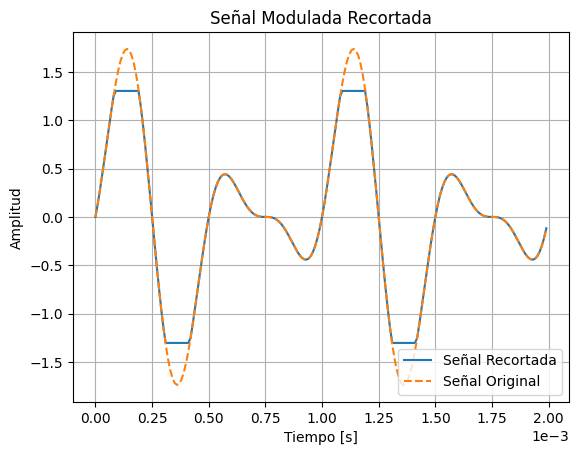

In [78]:
Amplitud_max = np.max(np.abs(señal_modulada)) # busco la amplitud maxima de la señal modulada
limite = 0.75 * Amplitud_max #pongo como limite el 75% de la amplitud maxima 

señal_recortada = np.clip(señal_modulada, -limite, limite) # recorto la señal modulada poniendo como limites (-limite + limite)


plt.figure()


plt.plot(tt, señal_recortada, label='Señal Recortada')
plt.plot(tt, señal_modulada, '--', label='Señal Original')


plt.title('Señal Modulada Recortada')   # título
plt.xlabel('Tiempo [s]')                 # eje x
plt.ylabel('Amplitud')                   # eje y
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) #agrego notacion cientifica en eje x

plt.grid(True)                           # grilla
plt.legend(loc='lower right')                             # muestra el label

plt.show()

Como se muestra en el gráfico, se definió un umbral correspondiente al 75% de la amplitud máxima de la señal original, estableciendo límites simétricos en los semiciclos positivos y negativos. Al aplicar el clipping, los valores que excedían dicho umbral fueron truncados, transformando los picos senoidales en crestas planas.

Luego, la potencia de la señal modulada periódica recortada será

In [79]:
potencia_señal_recortada = np.mean(señal_recortada**2)

print(f" Potencia de la señal modulada : {potencia_señal_recortada} watts")

 Potencia de la señal modulada : 0.5686786298973685 watts


Vemos que el valor de la potencia de la señal es menor al valor obtenido en la potencia de la señal modulada original, lo cual es esperable debido a que la señal recortada no posee los picos de la señal que aumentan el valor de la potencia.

### 1.5. Señal Cuadrada de 4 KHz

Ahora, genero una señal cuadrada de 4 KHz con un duty del 50%, la frecuencia de muestreo será de 400000 KHz para estar mucho mas por encima de Nyquist y la cantidad de muestras serán N = 200. La distancia entre muestras será de $ T = \frac{1}{400000} = 2,5.10^{-6} s $

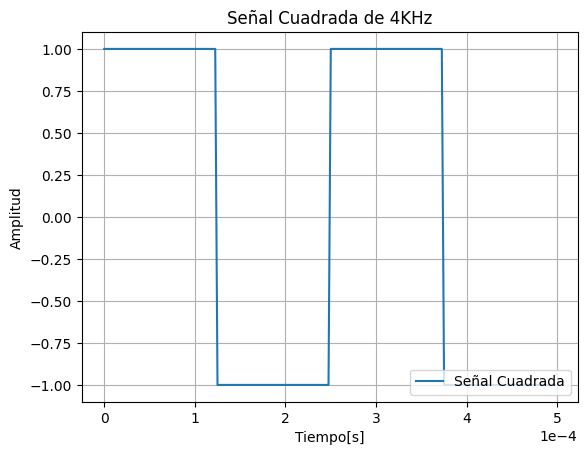

In [80]:
from scipy import signal

fm_cuadrada = 400000
nn_cuadrada = 200

t_cuadrada = np.arange(nn_cuadrada)/fm_cuadrada
frecuencia_cuadrada = 4000
señal_cuadrada = signal.square(2*np.pi*frecuencia_cuadrada*t_cuadrada, duty = 0.5)

plt.figure()
plt.plot(t_cuadrada, señal_cuadrada, label ='Señal Cuadrada')
plt.title("Señal Cuadrada de 4KHz")
plt.xlabel('Tiempo[s]')
plt.ylabel('Amplitud')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) #agrego notacion cientifica en eje x

plt.grid(True)
plt.legend(loc = 'lower right')

plt.show()

Como se observa en el grafico, obtenemos una señal cuadrada de 4 KHz, cuya potencia será

In [81]:
potencia_señal_cuadrada = np.mean(señal_cuadrada**2)

print(f" Potencia de la señal modulada : {potencia_señal_cuadrada} watts")

 Potencia de la señal modulada : 1.0 watts


### 1.6. Pulso rectangular de 10 ms

Para este caso considero una frecuencia de muestreo de 10000 Hz y una cantidad de muestras de N = 300. Para generar un pulso de duración T = 10 ms, voy a convertir el tiempo continuo en cantidad de muestras a través de la relación $ N = T.fm $. De esta manera, se obtiene la cantidad de muestras durante las cuales la señal toma el valor 1, mientras que en el resto del intervalo la señal vale 0.

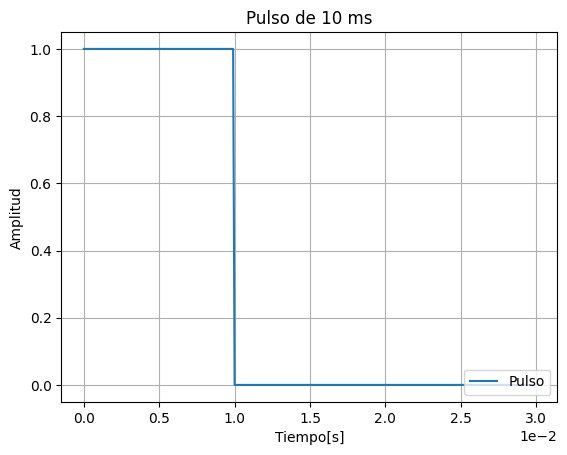

In [82]:
fm_pulso = 10000
nn_pulso = 300

t_pulso = np.arange(nn_pulso)/fm_pulso
pulso = np.zeros(nn_pulso) #creo un array de zeros de la cantidad de nn_pulso
duracion_pulso = int(0.01*fm_pulso)
pulso[:duracion_pulso] = 1

plt.figure()
plt.plot(t_pulso, pulso, label ='Pulso')
plt.title("Pulso de 10 ms")
plt.xlabel('Tiempo[s]')
plt.ylabel('Amplitud')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0)) #agrego notacion cientifica en eje x

plt.grid(True)
plt.legend(loc = 'lower right')

Como anticipamos previamente, de esta manera observamos gráficamente la creación de un pulso de T = 10 ms

Al tratarse de una señal de duración finita, corresponde calcular su energía. La misma se define como la sumatoria del módulo de la señal al cuadrado.

In [83]:
energia_pulso = np.sum(pulso**2)

print(f" Energía del pulso : {energia_pulso} J")

 Energía del pulso : 100.0 J


La energía en un pulso va a depender de su amplitud y del tiempo donde exista ese pulso, es decir, se calcula como $ E = N_{pulso}.A^{2} $ en mi caso como la cantidad de muestras $ N_{pulso} = 100 $ obtengo  $ E = 100.1^{2} = 100 J $